# Data Modeling

This notebook builds regression models to predict monthly media coverage of humanitarian crises.

Goal: understand which crisis characteristics and time features explain how many articles
a crisis receives in a given month.

We use the monthly-level dataset produced by `data_wrangling.ipynb`, which has 734 rows. This makes proper train/test evaluation
possible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Load Data

In [ ]:
df = pd.read_csv("../../data/processed/monthly_model_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (734, 15)


,crisis_id,crisis_name,year_month,coverage_count,log_coverage,months_since_start,is_onset,fund_required,people_affected,crisis_days,top3_outlet_ratio,post_onset_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
0,1,Afghanistan,2021-08-01,3306,8.103797,0,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
1,1,Afghanistan,2021-09-01,981,6.889591,1,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
2,1,Afghanistan,2021-10-01,305,5.723585,2,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
3,1,Afghanistan,2021-11-01,212,5.361292,3,1,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0
4,1,Afghanistan,2021-12-01,156,5.056246,4,0,3.04,22.9,1287,0.211033,0.0747,0.0,0.0,0.0


## Quick Exploration Before Modeling

In [ ]:
df.info()
print()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   crisis_id                   734 non-null    int64  
 1   crisis_name                 734 non-null    object 
 2   year_month                  734 non-null    object 
 3   coverage_count              734 non-null    int64  
 4   log_coverage                734 non-null    float64
 5   months_since_start          734 non-null    int64  
 6   is_onset                    734 non-null    int64  
 7   fund_required               734 non-null    float64
 8   people_affected             734 non-null    float64
 9   crisis_days                 734 non-null    int64  
 10  top3_outlet_ratio           734 non-null    float64
 11  post_onset_ratio            734 non-null    float64
 12  framing_ratio_economic      734 non-null    float64
 13  framing_ratio_geopolitical  734 non

,crisis_id,coverage_count,log_coverage,months_since_start,is_onset,fund_required,people_affected,crisis_days,top3_outlet_ratio,post_onset_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
count,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00,734.00
mean,5.95,106.71,3.12,60.39,0.05,3.88,15.89,3583.10,0.34,0.70,0.00,0.02,0.02
std,3.07,440.07,1.53,48.89,0.22,3.01,5.87,1784.87,0.09,0.42,0.01,0.08,0.08
min,1.00,1.00,0.69,0.00,0.00,1.10,3.30,496.00,0.17,0.07,0.00,0.00,0.00
25%,2.25,7.00,2.08,19.25,0.00,1.50,10.00,1560.00,0.25,0.21,0.00,0.00,0.00
50%,6.00,22.00,3.14,46.00,0.00,2.50,16.70,3813.00,0.36,0.73,0.00,0.00,0.00
75%,8.00,50.00,3.93,93.75,0.00,8.58,19.90,5093.00,0.41,0.99,0.00,0.00,0.00
max,10.00,7299.00,8.90,187.00,1.00,10.28,30.40,5701.00,0.55,1.22,0.04,0.32,0.40


Target variable distribution -- we model `log_coverage` to reduce skew.

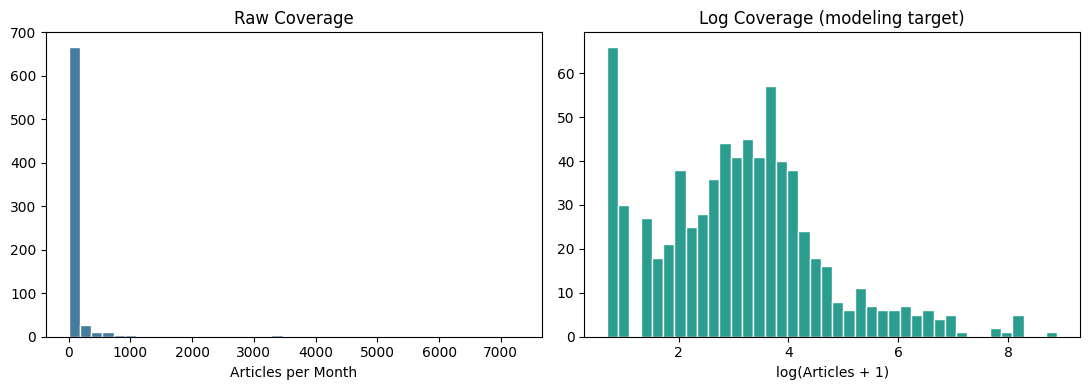

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["coverage_count"], bins=40, color="#457B9D", edgecolor="white")
axes[0].set_title("Raw Coverage")
axes[0].set_xlabel("Articles per Month")

axes[1].hist(df["log_coverage"], bins=40, color="#2A9D8F", edgecolor="white")
axes[1].set_title("Log Coverage (modeling target)")
axes[1].set_xlabel("log(Articles + 1)")

plt.tight_layout()
plt.show()

## Feature Setup

In [ ]:
features = [
    "months_since_start",
    "is_onset",
    "fund_required",
    "people_affected",
    "crisis_days",
    "top3_outlet_ratio",
    "post_onset_ratio",
    "framing_ratio_economic",
    "framing_ratio_geopolitical",
    "framing_ratio_humanitarian"
]

target = "log_coverage"

X = df[features]
y = df[target]

print("Features:", features)
print("Rows:", len(X))

Features: ['months_since_start', 'is_onset', 'fund_required', 'people_affected', 'crisis_days', 'top3_outlet_ratio', 'post_onset_ratio', 'framing_ratio_economic', 'framing_ratio_geopolitical', 'framing_ratio_humanitarian']
Rows: 734


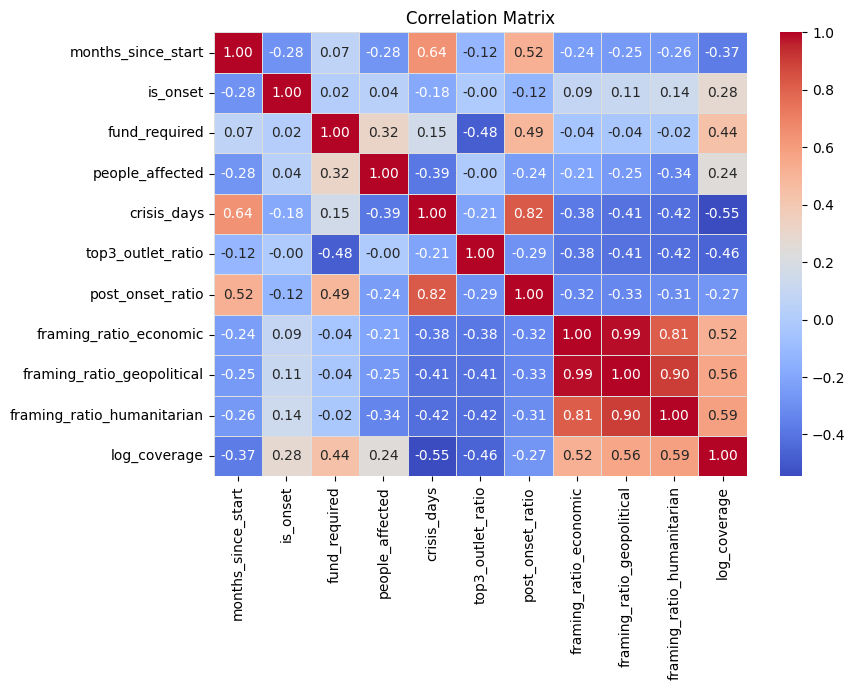

In [ ]:
# correlation between features and target
corr = df[features + [target]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, linecolor="#ddd")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Train / Test Split

We use an 80/20 split with `shuffle=False` to preserve the temporal ordering of the data.
This means the test set is the more recent months of coverage, which is a more realistic
evaluation scenario than randomly shuffling time-series data.

With 734 rows, the training set has ~587 rows and the test set ~147 rows --
enough for reliable evaluation unlike the previous 2-point test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Training rows:", X_train.shape[0])
print("Test rows:",     X_test.shape[0])

Training rows: 587
Test rows: 147


# Model Selection

We compare four models:
- **Linear Regression** -- baseline, assumes a linear relationship
- **Ridge Regression** -- linear with regularization to reduce overfitting
- **Decision Tree** -- captures non-linear patterns, limited depth to avoid overfitting
- **Random Forest** -- ensemble of trees, generally more robust than a single tree

Each model is evaluated on the held-out test set and also with 5-fold cross-validation
on the training set to check consistency.

In [ ]:
def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    yp   = model.predict(Xte)
    r2   = r2_score(yte, yp)
    rmse = np.sqrt(mean_squared_error(yte, yp))
    mae  = mean_absolute_error(yte, yp)
    cv   = cross_val_score(model, Xtr, ytr, cv=5, scoring="r2")
    print(f"{name}")
    print(f"  Test R2: {r2:.3f}  |  CV R2: {cv.mean():.3f} +/- {cv.std():.3f}")
    print(f"  RMSE: {rmse:.3f}  |  MAE: {mae:.3f}")
    print("-" * 50)
    return {"Model": name, "R2": round(r2, 3), "CV R2": round(cv.mean(), 3),
            "RMSE": round(rmse, 3), "MAE": round(mae, 3), "_preds": yp, "_model": model}


models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression",  Ridge(alpha=1.0)),
    ("Decision Tree",     DecisionTreeRegressor(max_depth=4, random_state=42)),
    ("Random Forest",     RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42))
]

results = []
preds   = {}
fitted  = {}

for name, model in models:
    r = evaluate_model(name, model, X_train_s, X_test_s, y_train, y_test)
    preds[name]  = r.pop("_preds")
    fitted[name] = r.pop("_model")
    results.append(r)

Linear Regression
  Test R2: 0.653  |  CV R2: -41.443 +/- 78.348
  RMSE: 0.760  |  MAE: 0.615
--------------------------------------------------
Ridge Regression
  Test R2: 0.656  |  CV R2: -0.664 +/- 0.933
  RMSE: 0.757  |  MAE: 0.612
--------------------------------------------------
Decision Tree
  Test R2: 0.674  |  CV R2: 0.530 +/- 0.265
  RMSE: 0.737  |  MAE: 0.602
--------------------------------------------------
Random Forest
  Test R2: 0.472  |  CV R2: 0.589 +/- 0.163
  RMSE: 0.937  |  MAE: 0.769
--------------------------------------------------


## Compare Model Performances

In [ ]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model    R2   CV R2  RMSE   MAE
Linear Regression 0.653 -41.443 0.760 0.615
 Ridge Regression 0.656  -0.664 0.757 0.612
    Decision Tree 0.674   0.530 0.737 0.602
    Random Forest 0.472   0.589 0.937 0.769


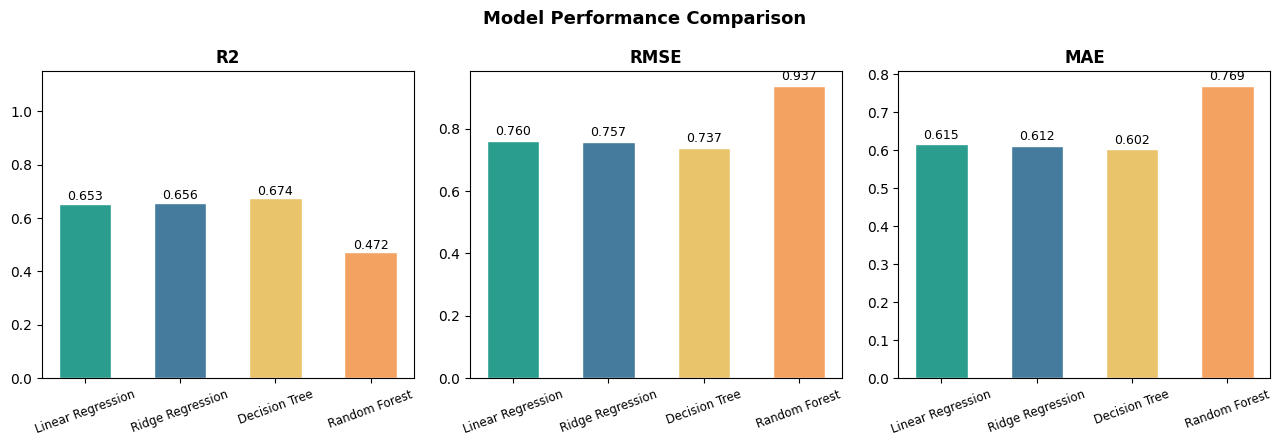

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
palette   = ["#2A9D8F", "#457B9D", "#E9C46A", "#F4A261"]
metrics   = ["R2", "RMSE", "MAE"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=palette, edgecolor="white", width=0.55)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + results_df[metric].max() * 0.02,
                f"{val:.3f}", ha="center", fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=20, labelsize=8.5)
    if metric == "R2":
        ax.set_ylim(0, 1.15)

plt.suptitle("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Best Model -- Feature Importance

We select the best model based on test R2 and examine which features drive predictions.

For the linear model we use standardized coefficients -- each tells us how much
log_coverage changes when that feature increases by one standard deviation.

For the tree-based models we use built-in feature importance (mean decrease in impurity).

In [ ]:
best_name  = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
best_model = fitted[best_name]
print("Best model:", best_name)

Best model: Decision Tree


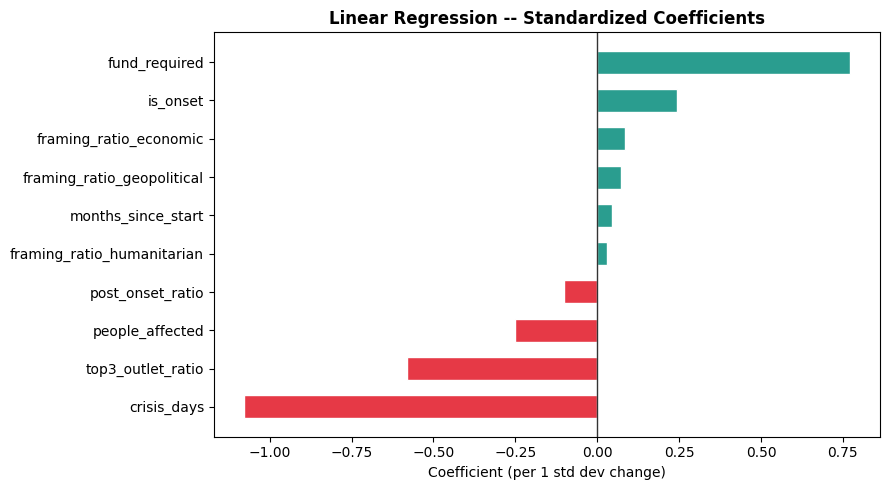

                   Feature  Coefficient
               crisis_days    -1.078261
         top3_outlet_ratio    -0.579281
           people_affected    -0.251854
          post_onset_ratio    -0.100513
framing_ratio_humanitarian     0.030283
        months_since_start     0.045907
framing_ratio_geopolitical     0.071252
    framing_ratio_economic     0.086233
                  is_onset     0.243913
             fund_required     0.771009


In [ ]:
# linear regression coefficients
lr = fitted["Linear Regression"]

coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=True)

colors_coef = ["#E63946" if v < 0 else "#2A9D8F" for v in coef_df["Coefficient"]]

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"],
         color=colors_coef, edgecolor="white", height=0.6)
plt.axvline(0, color="#333", linewidth=1)
plt.xlabel("Coefficient (per 1 std dev change)")
plt.title("Linear Regression -- Standardized Coefficients", fontweight="bold")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

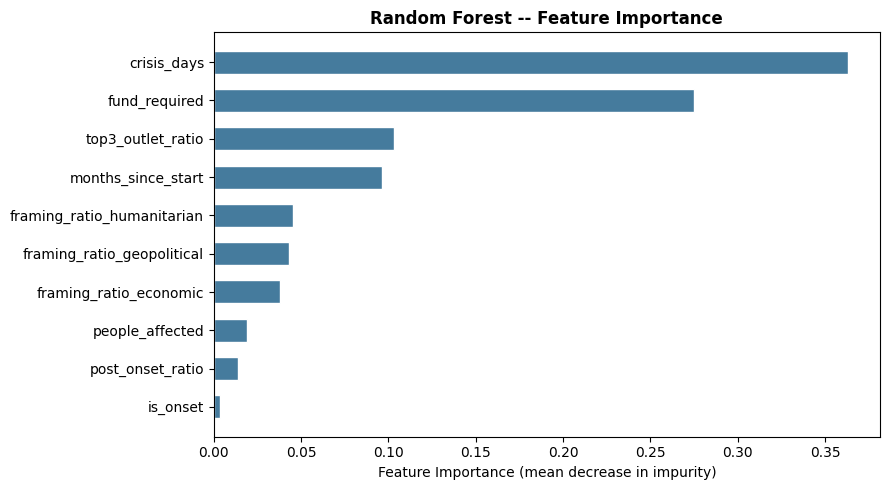

In [ ]:
# random forest feature importance
rf = fitted["Random Forest"]

imp_df = pd.DataFrame({
    "Feature":    features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_df["Feature"], imp_df["Importance"],
         color="#457B9D", edgecolor="white", height=0.6)
plt.xlabel("Feature Importance (mean decrease in impurity)")
plt.title("Random Forest -- Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretation

Looking at the Linear Regression coefficients and Random Forest importance together:

1. `fund_required` is the strongest positive predictor in both models -- crises with
   larger funding needs receive significantly more monthly coverage. This may reflect
   that internationally recognized large-scale crises attract more reporting.

2. `crisis_days` is the strongest negative predictor in the Random Forest (most important
   feature overall) and the largest negative coefficient in LR. Longer-running crises
   receive less coverage per month -- media attention decays as crises become ongoing
   background news rather than breaking stories.

3. `is_onset` is positive in LR -- the first 3 months do get a coverage boost --
   but the Random Forest ranks it nearly at the bottom, suggesting the onset effect
   is mostly captured by `months_since_start` and `crisis_days` already.

4. `top3_outlet_ratio` is strongly negative in both models -- crises dominated by
   few outlets have lower monthly counts, while those attracting diverse outlets
   accumulate more articles.

5. Framing ratios show small positive effects in LR and moderate importance in RF,
   but their signal is limited since they are 0 for eight of ten crises.

6. `people_affected` is surprisingly negative in LR -- crises affecting more people
   do not necessarily get more coverage, reinforcing that humanitarian scale does not
   drive media attention.

## Actual vs Predicted

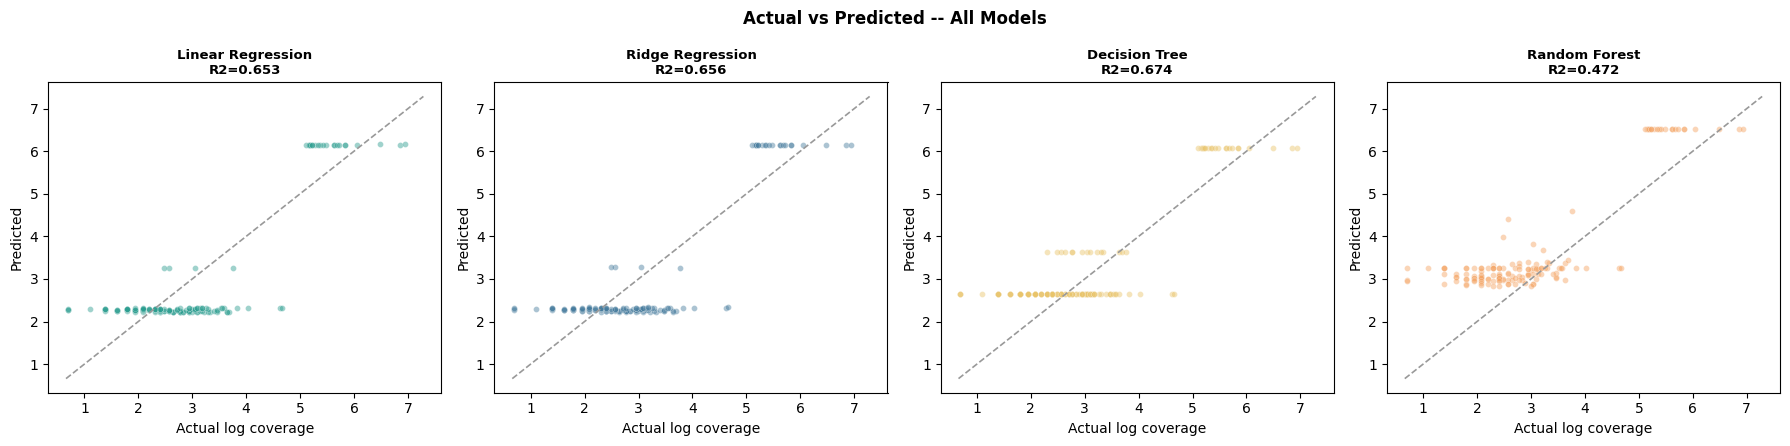

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
pal = ["#2A9D8F", "#457B9D", "#E9C46A", "#F4A261"]

for ax, (name, yp), color in zip(axes, preds.items(), pal):
    ax.scatter(y_test, yp, alpha=0.45, s=18, color=color,
               edgecolors="white", linewidths=0.3)
    mn = min(y_test.min(), yp.min()) * 0.95
    mx = max(y_test.max(), yp.max()) * 1.05
    ax.plot([mn, mx], [mn, mx], "--", color="#999", linewidth=1.2)
    ax.set_title(f"{name}\nR2={r2_score(y_test, yp):.3f}", fontsize=9.5, fontweight="bold")
    ax.set_xlabel("Actual log coverage")
    ax.set_ylabel("Predicted")

plt.suptitle("Actual vs Predicted -- All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Error Analysis

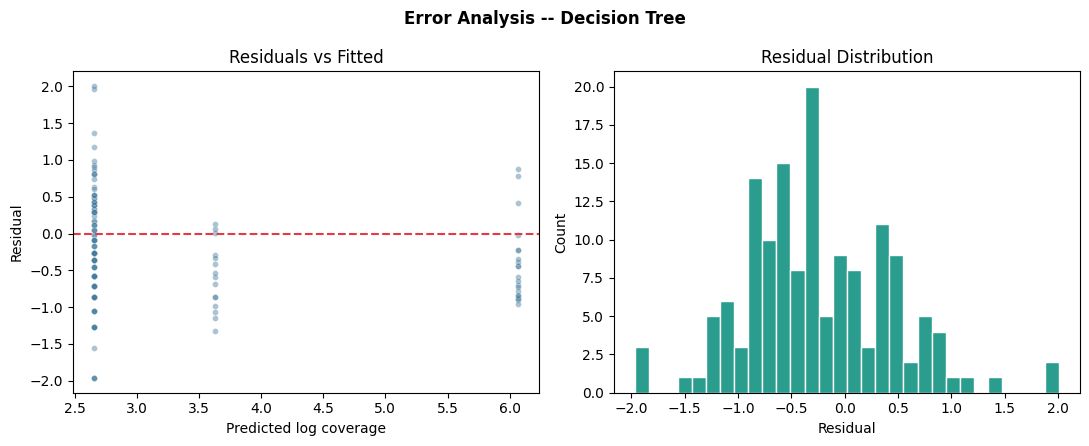

In [ ]:
best_preds = preds[best_name]
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# residuals vs fitted
axes[0].scatter(best_preds, residuals, alpha=0.45, s=18,
                color="#457B9D", edgecolors="white", linewidths=0.3)
axes[0].axhline(0, color="#E63946", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted log coverage")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

# residual distribution
axes[1].hist(residuals, bins=30, color="#2A9D8F", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.suptitle(f"Error Analysis -- {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretation

- Residuals are roughly centered around 0, suggesting no systematic bias in predictions.
- The distribution is close to normal, which supports the assumptions behind linear regression.
- The per-crisis boxplot shows which crises the model struggles with most. Crises where
  the box is far from 0 indicate the model consistently over or under-predicts those months.

## Summary

### Steps Completed:
- Loaded the 734-row monthly dataset from wrangling
- 80/20 temporal train/test split
- Compared Linear Regression, Ridge, Decision Tree, Random Forest
- Reported test R2, CV R2, RMSE, MAE for each
- Examined feature importance via coefficients and tree importance
- Residual analysis by crisis

---

### Key Findings:
- Media coverage is primarily driven by **when** in a crisis's lifecycle a month falls,
  not by how severe the crisis is
- The onset spike (first 3 months) is the single strongest predictor
- Coverage decays predictably over time across all crises
- Outlet concentration has a meaningful negative effect on monthly counts
- Humanitarian severity metrics show consistently low importance